In [139]:
from fredapi import Fred
import yfinance as yf
import pandas_datareader.data as web

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import linregress
from itertools import product
from typing import List, Tuple, Dict

In [547]:
### Current Tickers ###
mineral_stocks = [
    'GC=F',  # Gold
    'HG=F',  # Copper
    'PA=F',  # Palladium
    'PL=F',  # Platinum
    'SI=F',  # Silver
]

growth_stocks = [
    "NVDA",  # NVIDIA Corporation
    "MRVL",  # Marvell Technology Inc.
    "FTNT",  # Fortinet Inc.
    "AMD",   # Advanced Micro Devices, Inc.
    "CRM",   # Salesforce Inc.
    "ADBE",  # Adobe Inc.
    "ZM",    # Zoom Video Communications Inc.
    "SHOP",  # Shopify Inc.
    "SNAP",  # Snap Inc.
    "NET",   # Cloudflare, Inc.
    "TWLO",  # Twilio Inc.
    "MDB",   # MongoDB, Inc.
    "RBLX",  # Roblox Corporation
    "SNOW",  # Snowflake Inc.
    "PINS",  # Pinterest Inc.
    "TTD",   # The Trade Desk
    "DOCU",  # DocuSign, Inc.
    'SLAB',  # Silicon Laboratories Inc.
]

value_stocks = [
    "AAPL",  # Apple Inc.
    "MSFT",  # Microsoft Corporation
    "INTC",  # Intel Corporation
    "IBM",   # International Business Machines Corporation
    "ORCL",  # Oracle Corporation
    "CSCO",  # Cisco Systems, Inc.
    "HPE",   # Hewlett Packard Enterprise Co.
    "QCOM",  # Qualcomm Incorporated
    "TXN",   # Texas Instruments Incorporated
    "AVGO",  # Broadcom Inc.
    "MU",    # Micron Technology Inc.
    "LRCX",  # Lam Research Corporation
    "STX",   # Seagate Technology Holdings PLC
    "WDC",   # Western Digital Corporation
    "ADI",   # Analog Devices, Inc.
    "AMAT",  # Applied Materials, Inc.
    "MSI",   # Motorola Solutions, Inc.
    "VZ",    # Verizon Communications Inc.
    "TMUS"   # T-Mobile US, Inc.
]

market_indices = [
    "^DJI",     # Dow Jones Industrial Average (United States)
    "^GSPC",    # S&P 500 (United States)
    "^IXIC",    # NASDAQ Composite (United States)
    "^N225",    # Nikkei 225 (Japan)
    "^FTSE",    # FTSE 100 (United Kingdom)
    "^GDAXI",   # DAX (Germany)
    "^FCHI",    # CAC 40 (France)
    "HSI",      # Hang Seng Index (Hong Kong)
    "000001.SS",# Shanghai Composite Index (China)
    "^BSESN",   # SENSEX (India)
    "^NSEI",    # Nifty 50 (India)
    "^KS11",    # KOSPI (South Korea)
    "^AORD",    # All Ordinaries (Australia)
    "^BVSP",    # Bovespa (Brazil)
    "^MERV",    # MERVAL (Argentina)
    "^TWII",    # TAIEX (Taiwan)
    "^STI",     # Straits Times Index (Singapore)
    "^JKSE",    # Jakarta Composite Index (Indonesia)
    
]


In [548]:
start_date = "2023-01-01"


### Download Mineral Data ###
minerals = yf.download(mineral_stocks,start=start_date,auto_adjust=True,progress=False)["Close"]
minerals = minerals.dropna()
# minerals.columns = [(x[1] +' '+ x[0]).strip() for x in minerals.columns.to_list()]



## Download Closing Price of Growth and Value Stocks in One DataFrame ###
all_stocks = growth_stocks + value_stocks
stock_data = yf.download(all_stocks, start=start_date, progress=False,auto_adjust=True)['Close']


In [549]:
def generate_pairs(commodities_df:pd.DataFrame, stocks_df:pd.DataFrame, max_lag:int=3) -> List[Tuple[pd.Series, pd.Series, int]]:
    """
    Generate all possible (commodity, stock, lag) combinations.
    
    Parameters:
        commodities_df: Input Dataframe of commodity closing prices with datetime index
        stocks_df: Input Dataframe of commodity closing prices with datetime index
        max_lag: Number of days for commodity lag 
    
    Returns:
        list: list of tuples of (commodity_series, stock_series) tuples
    """
    pairs = []
    for commodity, stock, lag in product(commodities_df.columns, stocks_df.columns, range(0,max_lag+1)):
        commodity_series = commodities_df[commodity]
        stock_series = stocks_df[stock]

        commodity_series.name = commodity
        stock_series.name = stock

        pairs.append((commodity_series,stock_series,lag))
    return pairs

def compute_features_for_pairs(pairs:List[Tuple[pd.Series,pd.Series]], rolling_window:int=21, gradient:int=3) -> Dict[str,pd.DataFrame]:
    """
    Compute features for multiple (commodity, stock) pairs. 
    
    Parameters:
        pairs: List of (commodity_series, stock_series) tuples
        rolling_window: Window size for rolling correlation
        gradient: Number of days for gradient computation 
    
    Returns:
        Dict[str, pd.DataFrame]: Dictionary with key=pair_name and value=feature_DataFrame
    """
    
    results = {}
    for commodity, stock, lag in pairs:
        commodity_name = f'{commodity.name}_lag_{str(lag)}'
        stock_name = stock.name
        pair_name = f"{commodity_name}_{stock_name}"
        
        commodity_returns =  np.log(commodity).diff(1+lag)
        stock_returns = np.log(stock).diff(1)
        
        
        df = pd.DataFrame(
            {'price': stock,
             commodity_name: commodity_returns,
            stock_name: stock_returns,
        }).dropna()
        
        df['rolling_corr'] = df[commodity_name].rolling(window=rolling_window).corr(df[stock_name])
        df['gradient'] = df[commodity_name].rolling(window=gradient).apply(lambda x: linregress(range(gradient), x).slope, raw=True)

        results[pair_name] = df.dropna()
    return results


def rank_gradients_across_pairs(features_dict:Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Create a DataFrame where each column is the gradient of a pair
    Rank gradients across all pairs for each day.

    Returns:
        pd.DataFrame with dates as index and ranks as values (lower=stronger gradient)
    """
    gradients = []
    for pair_id, df in features_dict.items():
        gradient_series = df['gradient'].copy()
        gradient_series.name = pair_id
        gradients.append(gradient_series)
    
    all_gradients_df = pd.concat(gradients,axis=1)
    ranked_gradients = all_gradients_df.abs().rank(axis=1,method='min',ascending=False)

    return ranked_gradients

def get_top_n_pairs_per_day(ranked_df:pd.DataFrame, n:int=5) -> pd.DataFrame:
    """
    Return top-N ranked pair IDs per day.
    
    Returns:
        pd.DataFrame with dates as index and top-N pair_ids as columns
    """
    return ranked_df.apply(lambda row: row.nsmallest(n).index.tolist(), axis=1).to_frame(name="top_pairs")


def detect_trade_signals(df,min_streak=3):
    """
    Operations:
        1. Identifies rolling correlation.
        2. Identifies streaks of outlier rolling correlations. - higher and lower quartiles
        3. Filters for top 50% absolute gradient values.
        4. Calucluates trade signals based on sign of the gradient.
    
    Parameters:
        df: Input Dataframe of commodity closing prices with datetime index
        thershold: int - threshold of rolling correlation
        min_streak: int - minimum number of consecutive days of correlations above threshold
    
    Returns:
        pd.DataFrame: dataframe with rolling_corr, gradient, and trade_signal
    """
    quantiles = df.rolling_corr.quantile([.1,.9]).values
    low = quantiles[0]
    high = quantiles[1]
    
    
    # high = max(.6, quantiles[1])
    # low = min(-.6,quantiles[0])
    
    df['over_thresh'] = df['rolling_corr'].apply(lambda x: 1 if x > high or x < low  else 0)  
    df['streak'] = df['over_thresh'].astype(int).groupby(df['over_thresh'].ne(df['over_thresh'].shift()).cumsum()).cumsum()

    # Filter for streaks that meet min_streak requirement
    cutoff = df[(df['streak']>=min_streak)]['gradient'].abs().quantile(0.9)
    
    df['signal'] = df.apply(
        lambda row: 1 if row['gradient'] > cutoff and row['rolling_corr'] > high and row['streak'] >= min_streak
        else (-1 if row['gradient'] < -cutoff and row['rolling_corr'] < low and row['streak'] >= min_streak else 0),
        axis=1
    )
    return df

def detect_signals_from_top_pairs(top_3_per_day:pd.DataFrame, features:dict, min_streak:int = 3) -> pd.DataFrame:
    """
    Detect trade signals using top N ranked pairs per day and full signal logic.
    
    Parameters:
        top_3_per_day (pd.DataFrame): DataFrame with 'date' and 'pair' columns.
        features (dict): Dictionary of computed feature DataFrames for each pair.
        min_streak (int): Minimum streak length to trigger signal logic.

    Returns:
        pd.DataFrame: Signal DataFrame with date, pair, signal, gradient, rolling_corr, etc.
    """

    signal_rows = []
    for date, row in top_3_per_day.iterrows():
        for pair in row['top_pairs']:
            if pair not in features:
                continue

            feature_df = features[pair].copy()
            features_with_signals = detect_trade_signals(feature_df,min_streak=min_streak)

            if date in features_with_signals.index:
                signal_row = features_with_signals.loc[[date]].copy()
                signal_row['pair'] = pair
                signal_rows.append(signal_row[['pair','price','gradient','rolling_corr', 'signal','streak']])
    
    result_df = pd.concat(signal_rows).sort_index()
    return result_df


In [553]:
pairs = generate_pairs(commodities_df=minerals, stocks_df=stock_data, max_lag=3)
features = compute_features_for_pairs(pairs,rolling_window=4, gradient=5)
rankings = rank_gradients_across_pairs(features)
top_3_per_day = get_top_n_pairs_per_day(rankings, n=5)
signals = detect_signals_from_top_pairs(top_3_per_day,features,min_streak=3)

In [555]:
signals['lag'] = signals['pair'].str.extract(r'lag_(\d+)').astype(float)

In [556]:
signals

,pair,price,gradient,rolling_corr,signal,streak,lag
Date,,,,,,,
2023-01-10,PA=F_lag_0_AAPL,129.227463,-0.009891,0.974709,0,1,0.0
2023-01-10,PA=F_lag_0_ADBE,338.700012,-0.009891,0.499168,0,0,0.0
2023-01-10,PA=F_lag_0_ADI,162.580353,-0.009891,0.895298,0,1,0.0
2023-01-10,PA=F_lag_0_AMAT,105.974289,-0.009891,0.948878,0,1,0.0
2023-01-10,PA=F_lag_0_AMD,68.050003,-0.009891,0.461626,0,0,0.0
...,...,...,...,...,...,...,...
2025-04-17,HG=F_lag_2_AAPL,196.979996,-0.018716,0.480721,0,0,2.0
2025-04-17,HG=F_lag_2_ADBE,348.799988,-0.018716,-0.196930,0,0,2.0
2025-04-17,HG=F_lag_2_ADI,176.270004,-0.018716,0.235714,0,0,2.0


In [575]:


above_streak = signals[(signals.streak>3)]
top_streaks = above_streak[above_streak.streak<above_streak.streak.quantile(.99)]
top_streaks.groupby('pair')['streak'].mean() - top_streaks.groupby('pair')['lag'].first().values


pair
HG=F_lag_3_AAPL    1.0
HG=F_lag_3_AMAT    1.0
HG=F_lag_3_AMD     1.0
PA=F_lag_1_ADBE    3.0
PA=F_lag_1_ADI     3.0
PA=F_lag_2_AMD     3.0
PA=F_lag_3_ADBE    1.5
PA=F_lag_3_ADI     1.0
PA=F_lag_3_AMD     1.0
PL=F_lag_2_AAPL    2.0
PL=F_lag_2_AMAT    2.0
SI=F_lag_2_AMAT    2.0
SI=F_lag_3_AAPL    1.0
SI=F_lag_3_ADI     1.0
SI=F_lag_3_AMAT    1.0
SI=F_lag_3_AMD     1.5
Name: streak, dtype: float64

In [573]:
signals[signals.signal !=0].groupby('pair')['streak'].mean()

pair
HG=F_lag_3_ADI     3.0
HG=F_lag_3_AMD     4.0
PA=F_lag_1_AMAT    3.0
PA=F_lag_2_AAPL    3.0
PA=F_lag_2_ADI     3.0
PA=F_lag_2_AMAT    3.0
PA=F_lag_2_AMD     3.0
PA=F_lag_3_ADBE    5.0
PL=F_lag_2_AMAT    3.0
PL=F_lag_2_AMD     3.0
PL=F_lag_3_ADBE    3.0
SI=F_lag_2_AAPL    3.0
SI=F_lag_2_ADBE    3.0
SI=F_lag_2_ADI     3.0
Name: streak, dtype: float64

In [503]:
active_signals = signals[signals.signal!=0]
active_signals.loc[:,'stock_name'] = active_signals.loc[:,'pair'].str.split('_').str[-1]
active_sig_piv = active_signals.pivot_table(index='Date',columns=['stock_name'],values='price')
active_sig_piv.head()

/var/folders/k0/9f6yzffx4y5crxk0tkwzmj500000gn/T/ipykernel_70236/262453988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_signals.loc[:,'stock_name'] = active_signals.loc[:,'pair'].str.split('_').str[-1]


stock_name,AAPL,ADBE
Date,,
2023-03-03,149.522110,NaN
2023-03-22,NaN,361.709991
2023-04-27,166.728592,371.420013
2023-05-05,171.837067,348.399994
2023-05-08,NaN,344.059998


In [504]:
active_price = stock_data.loc[:,active_sig_piv.columns.to_list()]
active_price.head()

Ticker,AAPL,ADBE
Date,,
2023-01-03,123.632530,336.920013
2023-01-04,124.907700,341.410004
2023-01-05,123.583092,328.440002
2023-01-06,128.130234,332.750000
2023-01-09,128.654160,341.980011


In [507]:
from datetime import timedelta

# Make sure the index of stock_prices is datetime
stock_data.index = pd.to_datetime(stock_data.index)

# Create a list to store percent changes
percent_changes = []

for idx, row in active_signals.iterrows():
    stock = row['stock_name']
    signal_date = row.name  # since Date is the index
    price_on_signal_day = stock_data.loc[signal_date, stock] if stock in stock_data.columns and signal_date in stock_data.index else None
    
    date_plus_3 = signal_date + timedelta(days=3)
    # Find the closest future trading day if exact date is not in index
    future_dates = stock_data.index[stock_data.index > signal_date]
    future_price_date = future_dates[future_dates <= date_plus_3].max() if not future_dates.empty else None
    
    if price_on_signal_day and future_price_date and future_price_date in stock_data.index:
        price_after_3_days = stock_data.loc[future_price_date, stock]
        percent_change = (price_after_3_days - price_on_signal_day) / price_on_signal_day
    else:
        percent_change = None

    percent_changes.append(percent_change)

# Add result to DataFrame
active_signals['3_day_return'] = percent_changes


/var/folders/k0/9f6yzffx4y5crxk0tkwzmj500000gn/T/ipykernel_70236/4284243430.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_signals['3_day_return'] = percent_changes


In [ ]:
active_signals['curr_portfolio'] = 10000

positions = [2,2,2]

max_constraint = 0.3

curr_investable = max_constraint * active_signals['curr_portfolio'] 

dollars_in_position = curr_investable * (1/len(positions))
                          
active_signals['final_position_value'] = (1 + active_signals['3_day_return'] ) * dollars_in_position

active_signal['curr_portfolio'] += active_signal['curr_portfolio']

/var/folders/k0/9f6yzffx4y5crxk0tkwzmj500000gn/T/ipykernel_70236/485293555.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_signals['curr_portfolio'] = 10000
/var/folders/k0/9f6yzffx4y5crxk0tkwzmj500000gn/T/ipykernel_70236/485293555.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_signals['final_position_value'] = (1 + active_signals['3_day_return'] ) * dollars_in_position


NameError: name 'active_signal' is not defined

In [519]:
active_signals

,pair,price,gradient,rolling_corr,signal,stock_name,3_day_return,net_gain,final_position_value
Date,,,,,,,,,
2023-03-03,HG=F_lag_1_AAPL,149.522110,-0.030362,-0.306392,-1,AAPL,0.018539,1018.539290,1018.539290
2023-03-22,PA=F_lag_3_ADBE,361.709991,0.053762,0.330399,1,ADBE,0.036632,1036.631557,1036.631557
2023-04-27,PA=F_lag_1_AAPL,166.728592,0.048728,0.497263,1,AAPL,0.007541,1007.541052,1007.541052
2023-04-27,PA=F_lag_1_ADBE,371.420013,0.048728,0.495121,1,ADBE,0.016531,1016.531107,1016.531107
2023-05-05,PA=F_lag_2_AAPL,171.837067,0.054157,0.439538,1,AAPL,-0.000403,999.596679,999.596679
2023-05-05,PA=F_lag_2_ADBE,348.399994,0.054157,0.558737,1,ADBE,-0.012457,987.543064,987.543064
2023-05-08,PA=F_lag_3_ADBE,344.059998,0.070516,0.312472,1,ADBE,-0.007208,992.791923,992.791923
2023-06-21,PA=F_lag_3_AAPL,182.375244,-0.047076,-0.270019,-1,AAPL,0.014786,1014.785883,1014.785883
2023-06-22,PA=F_lag_3_AAPL,185.389069,-0.052953,-0.349746,-1,AAPL,-0.001711,998.288758,998.288758


In [459]:
import backtester
import importlib
importlib.reload(backtester)
from backtester import Backtester
from backtester import Strategy


Final Portfolio Value: 750.92
Total Return: -92.49%
Annualized Return: -69.20%
Annualized Volatility: 216.65%
Sharpe Ratio: -0.33
Sortino Ratio: -0.50
Maximum Drawdown: -38.69%


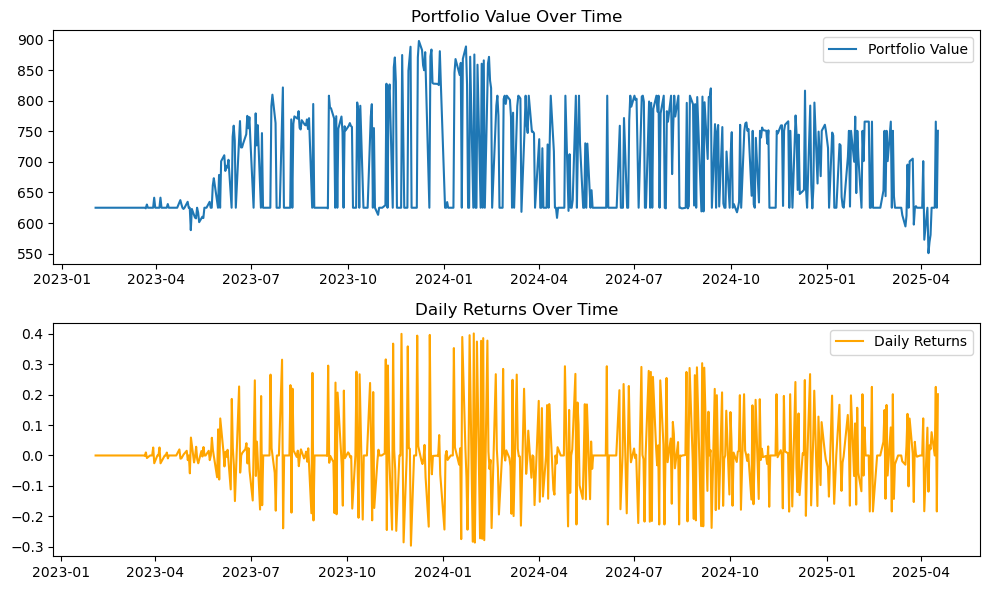

In [460]:
data = signals[['pair','price','signal']].dropna()
backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()

In [483]:
data[data.pair == 'PL=F_lag_0_AAPL']

active_pairs = data[data.signal!=0].pair.unique()
active_data = data[data.pair.isin(active_pairs)]
data['2024-08-16':].head(20)

,pair,price,signal
Date,,,
2024-08-16,SI=F_lag_1_AAPL,225.553589,1
2024-08-16,SI=F_lag_1_ADBE,553.460022,0
2024-08-19,SI=F_lag_2_AAPL,225.393936,0
2024-08-19,SI=F_lag_2_ADBE,563.119995,0
2024-08-20,PA=F_lag_3_AAPL,226.012573,0
2024-08-20,PA=F_lag_3_ADBE,562.250000,0
2024-08-21,PA=F_lag_0_AAPL,225.902802,1
2024-08-21,PA=F_lag_0_ADBE,565.789978,0
2024-08-22,SI=F_lag_3_AAPL,224.036926,0


In [ ]:
unique_pairs = data.pairs.unique() 
pairs_dict = {}
pairs

In [462]:
# backtester.portfolio_history

In [524]:
backtester.trade_log

{'PA=F_lag_3_ADBE': [{'date': Timestamp('2023-03-22 00:00:00'),
   'type': 'BUY',
   'shares': 0.8611871592125653,
   'price': 361.7099914550781,
   'value': 312.5,
   'commission': 1.0,
   'cash_remaining': 0.0},
  {'date': Timestamp('2024-09-18 00:00:00'),
   'type': 'SELL',
   'shares': 0.8611871592125653,
   'price': 508.1300048828125,
   'value': 437.5950354156962,
   'commission': 1.0,
   'cash_remaining': 436.5950354156962}],
 'PA=F_lag_1_AAPL': [{'date': Timestamp('2023-04-27 00:00:00'),
   'type': 'BUY',
   'shares': 1.868305828141552,
   'price': 166.7285919189453,
   'value': 312.5,
   'commission': 1.0,
   'cash_remaining': 0.0},
  {'date': Timestamp('2024-04-11 00:00:00'),
   'type': 'SELL',
   'shares': 1.868305828141552,
   'price': 174.21737670898438,
   'value': 325.4913402689278,
   'commission': 1.0,
   'cash_remaining': 324.4913402689278}],
 'PA=F_lag_1_ADBE': [{'date': Timestamp('2023-04-27 00:00:00'),
   'type': 'BUY',
   'shares': 0.8386731698307023,
   'price': 

In [469]:
backtester.portfolio_history

{'PL=F_lag_0_AAPL': [312.5, 312.5, 312.5, 312.5, 312.5],
 'PL=F_lag_0_ADBE': [312.5, 312.5, 312.5, 312.5, 312.5],
 'SI=F_lag_1_AAPL': [312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  311.5,
  306.44266730618835,
  314.46270893824055,
  317.99042976942036,
  335.00499628599334,
  341.8060856602813,
  342.06821392136857,
  349.6831884712905,
  344.59272886804655,
  352.1525761946383,
  314.89146218207696,
  260.1615510341039,
  238.12003923046322],
 'SI=F_lag_1_ADBE': [312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5],
 'PL=F_lag_1_AAPL': [312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,
  312.5,


In [468]:
backtester.daily_portfolio_values

[625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 624.0,
 630.2780617494366,
 625.0,
 625.0,
 625.0,
 625.0,
 641.3873708470094,
 625.0,
 625.0,
 625.0,
 641.4907091010995,
 625.0,
 625.0,
 625.0,
 631.0445309361821,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 625.0,
 637.4603595035078,
 630.7861590196104,
 625.0,
 623.0,
 625.0,
 634.713170363112,
 625.0,
 625.0,
 588.3055100725148,
 623.0,
 608.8000518961675,
 607.5857748479161,
 625.0,
 617.2253661631493,
 601.3852430703936,
 610.1865768887999,
 608.1443794907307,
 625.0,
 625.0,
 625.0,
 634.6834420443437,
 625.0,
 625.0370616321038,
 661.4243611317127,
 673.3098403396191,
 625.0,
 678.6936463004688,
 625.0,
 701.1293835164386,
 710.9265215645623,
 685.2993219665736,
 693.5833233000828,
 690.5869974578386,
 703.4789

In [403]:
data['2023-03-01':].head(50)

,stock_price,signal,positions,portfolio_values
Date,,,,
2023-03-01,143.859207,0,0,10000.000000
2023-03-01,323.380005,0,0,10000.000000
2023-03-02,144.453232,0,0,10000.000000
2023-03-02,333.500000,0,0,10000.000000
2023-03-03,149.522110,-1,-2,10000.000000
2023-03-03,344.040009,0,0,10000.000000
2023-03-06,152.294144,0,0,10000.000000
2023-03-06,347.019989,0,0,10000.000000
2023-03-07,150.086441,0,0,10000.000000


In [ ]:
# def print_signals(signals, commodity_name, stock_name, lag):
#     """Prints trade signals in a readable format."""
#     if not signals.empty:
#         print(f"\n📢 Trade Signals for {commodity_name} (lag={lag}) & {stock_name}")
#         print(signals[['rolling_corr', 'gradient', 'signal']])

# def main(commodities, stocks, threshold=0.95, min_streak=3, lag=1):
#     """
        
#     """
#     # Generate pairs
#     pairs = generate_pairs(commodities, stocks)

#     # Process each pair
#     for commodity, stock in pairs:
#         # print(f"\n🔄 Processing {commodity} & {stock}...")
#         df_features = compute_features(commodities[commodity], stocks[stock], rolling_window=21, gradient=3, lag=lag)
#         trade_signals = detect_trade_signals(df_features, threshold=threshold, min_streak=min_streak)
        
#         print_signals(trade_signals, commodity, stock, lag=lag)


# for lag in range(0, 6):
#     print(f"\n🚀 Running strategy with LAG = {lag}")
#     main(minerals, stock_data, min_streak=3, lag=lag)